                                                                                                by Maria 

# <center> SVM Project pt. 2

In [1]:
import numpy as np
import pandas as pd
import math
import pickle
import os
import cv2
import matplotlib.pyplot as plt
from matplotlib import cm
import plotly.express as px
import seaborn as sns; sns.set()

from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
from sklearn.metrics import recall_score, precision_score, accuracy_score, balanced_accuracy_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, confusion_matrix, accuracy_score, precision_score, recall_score, precision_recall_curve, f1_score, roc_auc_score, auc, roc_curve

from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn import svm
from sklearn.svm import SVC, SVR 
from sklearn.decomposition import PCA
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.datasets import make_blobs, make_circles
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from skimage.feature import hog
from skimage import exposure

from sklearn.manifold import TSNE
from sklearn.utils import shuffle


import torch
import torch.nn as nn
import torch.optim as optim

from scipy import stats

from PIL import Image


from skimage.io import imread, imshow
from skimage import color
from skimage.transform import resize
from skimage.feature import hog
from skimage import exposure
%matplotlib inline

import glob
import re

import multiprocessing
import warnings
warnings.filterwarnings("ignore")

# 0 Исходные данные

## Задание №1
Ваша цель – применить свои знания по SVM для классификации изображений.
Для этой задачи будем использовать классический датасет MNIST, который содержит рукописные цифры. Всего 10 классов - числа от 0 до 9. Для экономии времени при тестировании ваших идей можете для начала использовать урезанную версию датасета – Reduced MNIST. Также можете его загрузить напрямую из sklearn, tensorflow или pytorch библиотеки.
1. Датасет состоит из одноканальных изображений (grayscale) разрешением 28х28 пикселей. Каждый пиксель - это целое число от 0 до 255. В первую очередь вам необходимо преобразовать данные изображения в вектора. Для этого можно считывать картинки построчно и конкатенировать каждую новую строчку с предыдущей. В итоге любое изображение из датасета можно будет представить в виде вектора длиной 784. Назовем его color feature vector.
2. Как только вы преобразуете изображения в вектора, примените накопленные знания по SVM для тренировки классификатора, также выберите подходящую метрику для своей модели.
3. Для отображения многомерных пространств на двумерную плоскость можете использовать t-SNE алгоритм.
4. Как только у вас получится подобрать подходящие гиперпараметры для классификатора, попробуйте увеличить размерность векторов за счёт применения гистограммы направленных градиентов (Histogram of Oriented Gradients - HOG). Фактически вы можете применить данную операцию к любому изображению и также построчно создать 784-мерный вектор, состоящий только из HOG-фичей. Назовем его hog-feature vector. Затем вы можете конкатенировть color feature и hog-feature вектора и получить финальный 1568-мерный feature vector.
5. Попробуйте снова применить SVM для классификации полученных векторов в многомерном пространстве. Как изменятся результаты? Лучше происходит разделение классов в пространстве более высокой размерности или нет?


# 1. EDA (Exploratory Data Analysis)

In [111]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist["data"], mnist["target"]

In [600]:
mnist;

In [113]:
print(X.shape, y.shape)

(70000, 784) (70000,)


### Проверка на пропуски

In [114]:
print("NaN in X:", X.isnull().any().any())
print("NaN in y:", y.isnull().any())

NaN in X: False
NaN in y: False


### Нормируем значения пикселей на максимум (значения пикселей находятся в диапазоне от 0 до 255)

In [115]:
X /= 255

### Преобразуем таргет в целочисленный 

In [116]:
y

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [117]:
y = y.astype(int)

In [118]:
y

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: int64

In [119]:
X

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Читаем данные redused mnist

In [121]:
train_dir='/home/mary/Desktop/MIPT/СКОЛТЕХ_ИНЖПРАК/SKOLTECH_ML_prep/task_4/data/Reduced Training data'
test_dir='/home/mary/Desktop/MIPT/СКОЛТЕХ_ИНЖПРАК/SKOLTECH_ML_prep/task_4/data/Reduced Testing data'
train_list=[]
test_list=[]

for i in range(10):
    train_list.append(glob.glob('{}/{}/*.jpg'.format(train_dir,i)))
    test_list.append(glob.glob('{}/{}/*.jpg'.format(test_dir,i)))

train_list = [item for sublist in train_list for item in sublist]
test_list = [item for sublist in test_list for item in sublist]

train_data = np.array([np.array(Image.open(fname)) \
                              for fname in train_list])
test_data = np.array([np.array(Image.open(fname)) \
                             for fname in test_list])

train_label=np.array([list(map(int, re.findall(r'\b\d\b', fname)))[0]  for fname in train_list])
test_label=np.array([list(map(int, re.findall(r'\b\d\b', fname)))[0]  for fname in test_list])

X_train_reduced, y_train_reduced = shuffle(train_data.reshape(-1, 28*28)/255, train_label)
X_test_reduced, y_test_reduced= shuffle(test_data.reshape(-1, 28*28)/255, test_label)

## 1.1. Визуализация нескольких рандомно выбранных картинок

In [122]:
images = X.to_numpy().reshape(-1, 28, 28)

In [123]:
indices = np.random.choice(len(images), 20, replace=False)
sample_images = images[indices]

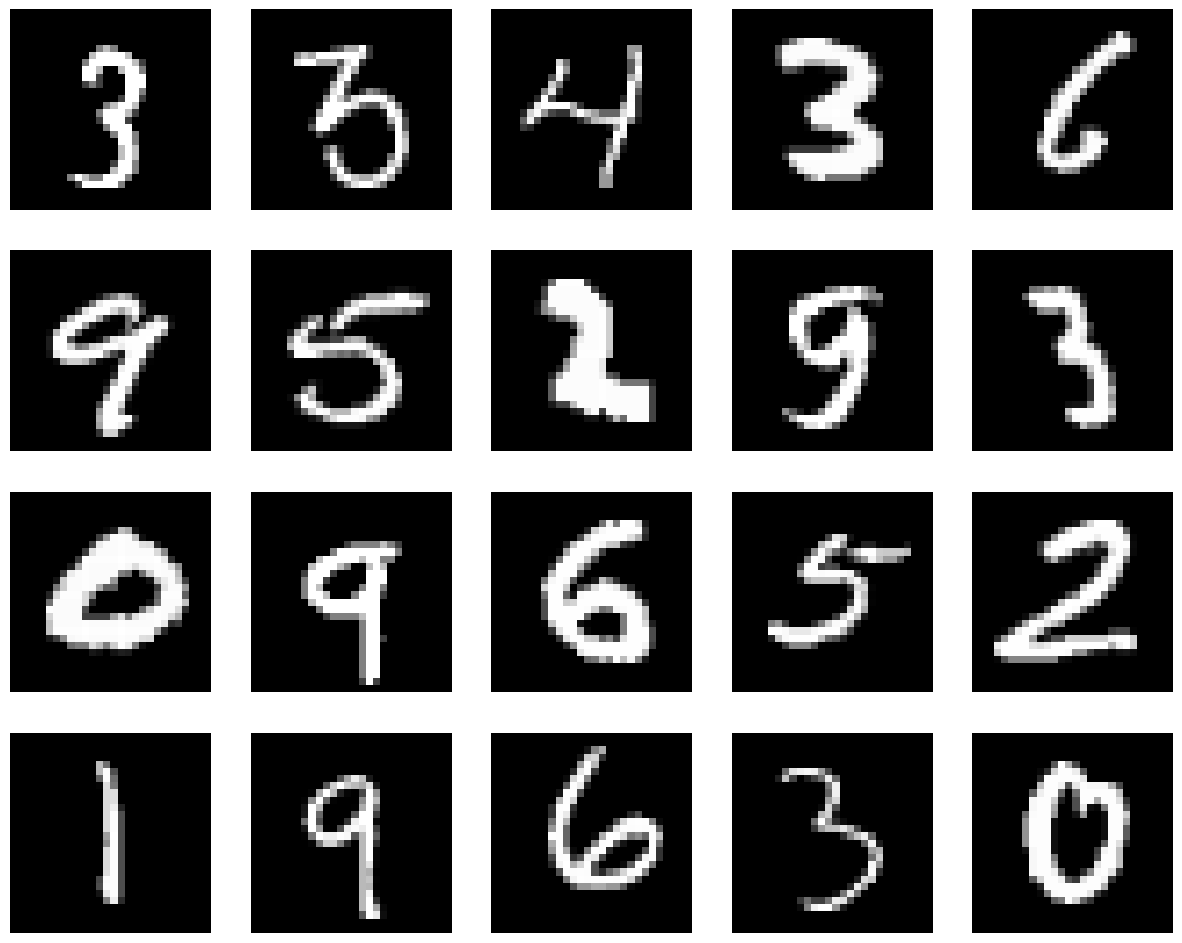

In [39]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_images[i], cmap='gray')
    ax.axis('off')  
    
plt.show()

<Axes: >

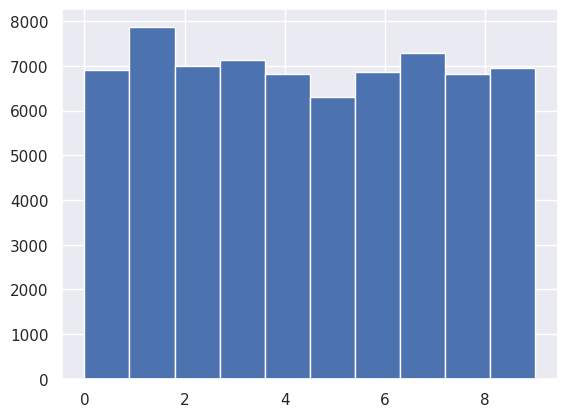

In [163]:
y.hist()

Классы распределены равномерно

## 1.2 Визуализация с t-SNE

In [141]:
tsne = TSNE(n_components=2, random_state=42)
X_reduced = tsne.fit_transform(X_train) 

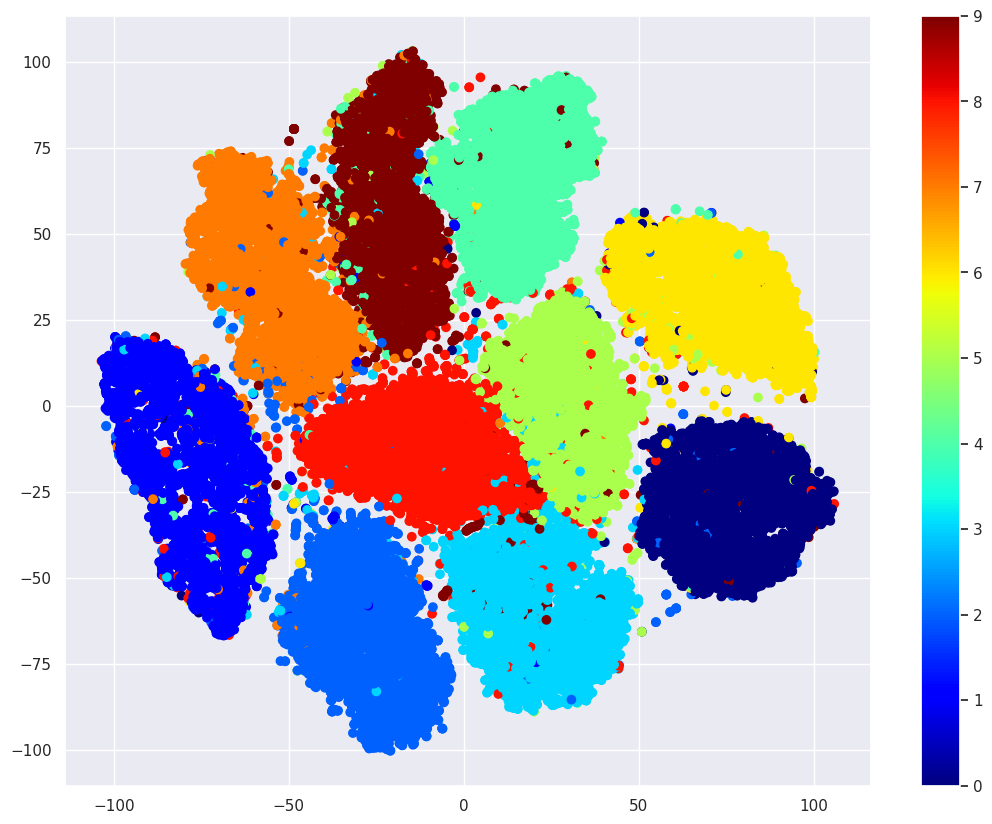

In [142]:
plt.figure(figsize=(13,10))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_train, cmap="jet")
plt.colorbar()
plt.show()

t-SNE для reduced данных

In [146]:
X_train_reduced.shape

(10000, 784)

In [147]:
tsne = TSNE(n_components=2, random_state=42)
X_reduced = tsne.fit_transform(X_train_reduced) 

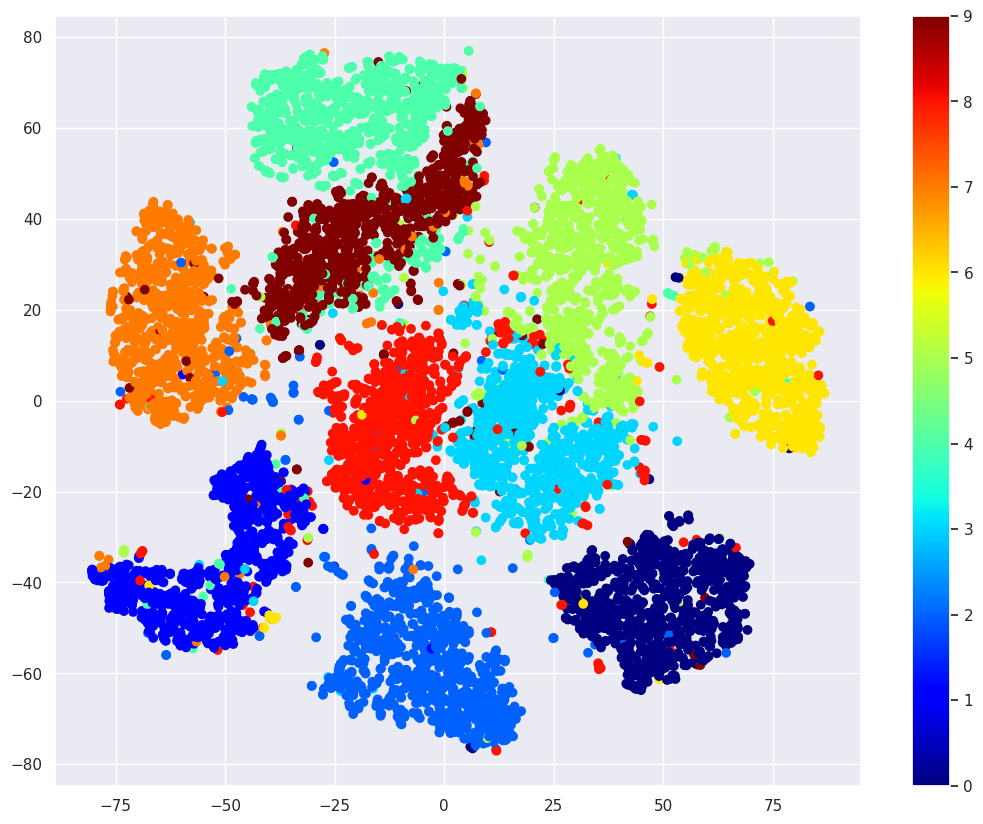

In [148]:
plt.figure(figsize=(13,10))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_train_reduced, cmap="jet")
plt.colorbar()
plt.show()

Вывод: можем подбирать оптимальную модель для mnist на reduced_mnist, потому что данные разделимы в обеих бд.

В принципе подбирать параметры особо не нужно, тк задача разделить эти классы - практически линейная в 2D

# 2. SVC

In [2]:
def metrics(y_test, y_pred):
    cf_matrix = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    ac_score = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    return cf_matrix, ac_score, prec, rec, f1

In [122]:
c_array = [0.1, 1, 10]
gamma_array = [0.1, 1, 10]

In [81]:
def model_metrics_counter(c, gamma):
    BM = np.zeros(4)
    Y_PRED_PROB = np.array([])
    Y_TEST = np.array([])
    CONFUSION_MATRIX = np.zeros((10, 10))
    CV = ShuffleSplit(n_splits=5, random_state=0, test_size=0.2)
    for i, (train_index, test_index) in enumerate(CV.split(X)):
        print(len(train_index), len(test_index))
        x_train, x_test = X.loc[train_index], X.loc[test_index]
        y_train = y.loc[train_index]
        y_test = y.loc[test_index]

        model = SVC(kernel='rbf', C=c, gamma=gamma)
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)

        binm = metrics(y_test, y_pred)
        CONFUSION_MATRIX += binm[0]
        BM += binm[1:]
    BM /= 5 
    
    return BM, CONFUSION_MATRIX

In [3]:
def confusion_matrix_visualisation(cm):
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, square=True, annot=True, cmap='BuPu')
    plt.title('Confusion Matrix')
    plt.ylabel('Действительный класс')
    plt.xlabel('Предсказанный класс')

    plt.tight_layout()
    plt.show()

56000 14000
56000 14000
56000 14000
56000 14000
56000 14000
RBF kernel c = 10, gamma = 10
 Accuracy_score = 0.9781714285714285
 Precision = 0.9781827239884056, Recall = 0.9781714285714285
 F1_score = 0.9781613281157251



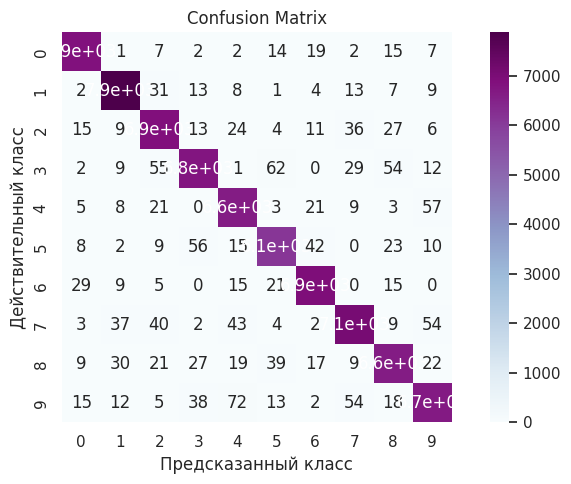

In [135]:
#for c in c_array:
#    for g in gamma_array:
BM, CONFUSION_MATRIX = model_metrics_counter(1, 'scale')
print(f'RBF kernel c = {1}, gamma = {scale}\n Accuracy_score = {BM[0]}\n Precision = {BM[1]}, Recall = {BM[2]}\n F1_score = {BM[3]}\n')
confusion_matrix_visualisation(CONFUSION_MATRIX)
        

Вывод: svc итак хорошо работает, добавление HOG скорее всего увеличит время работы

In [128]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [129]:
svm_clf = SVC(gamma='scale')
svm_clf.fit(X_train, y_train)

SVC()

In [130]:
y_pred = svm_clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9764285714285714


# 4. Эксперименты

In [485]:
htmp = np.zeros((28, 28))
for x in images:
    htmp+=x

<Axes: >

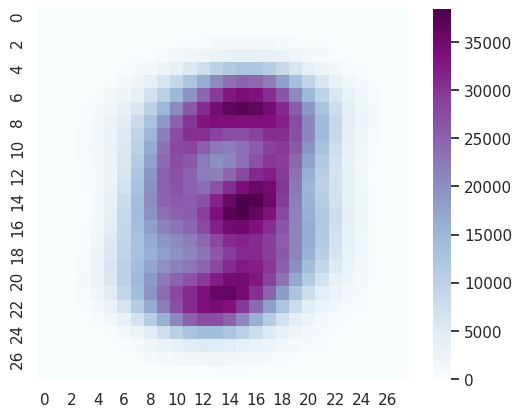

In [161]:
sns.heatmap(htmp, square=True, annot=False, cmap='BuPu')

Можем наблюдать, что информативная часть картинки занимает меньше места, чем 28 * 28, поэтому для ускорения работы и улучшения качетсва целесообразно обрезать изображения до размера 21 * 21

In [125]:
images_cropped = images[:, 4:25, 4:25]

In [126]:
images_cropped.shape

(70000, 21, 21)

Теперь сожмём изображения

In [127]:
images_cropped_compressed = np.array([resize(image, (8, 8)) for image in images_cropped])

In [128]:
images_cropped_compressed.shape

(70000, 8, 8)

In [490]:
indices = np.random.choice(len(images_cropped_compressed), 20, replace=False)
sample_images = images_cropped_compressed[indices]

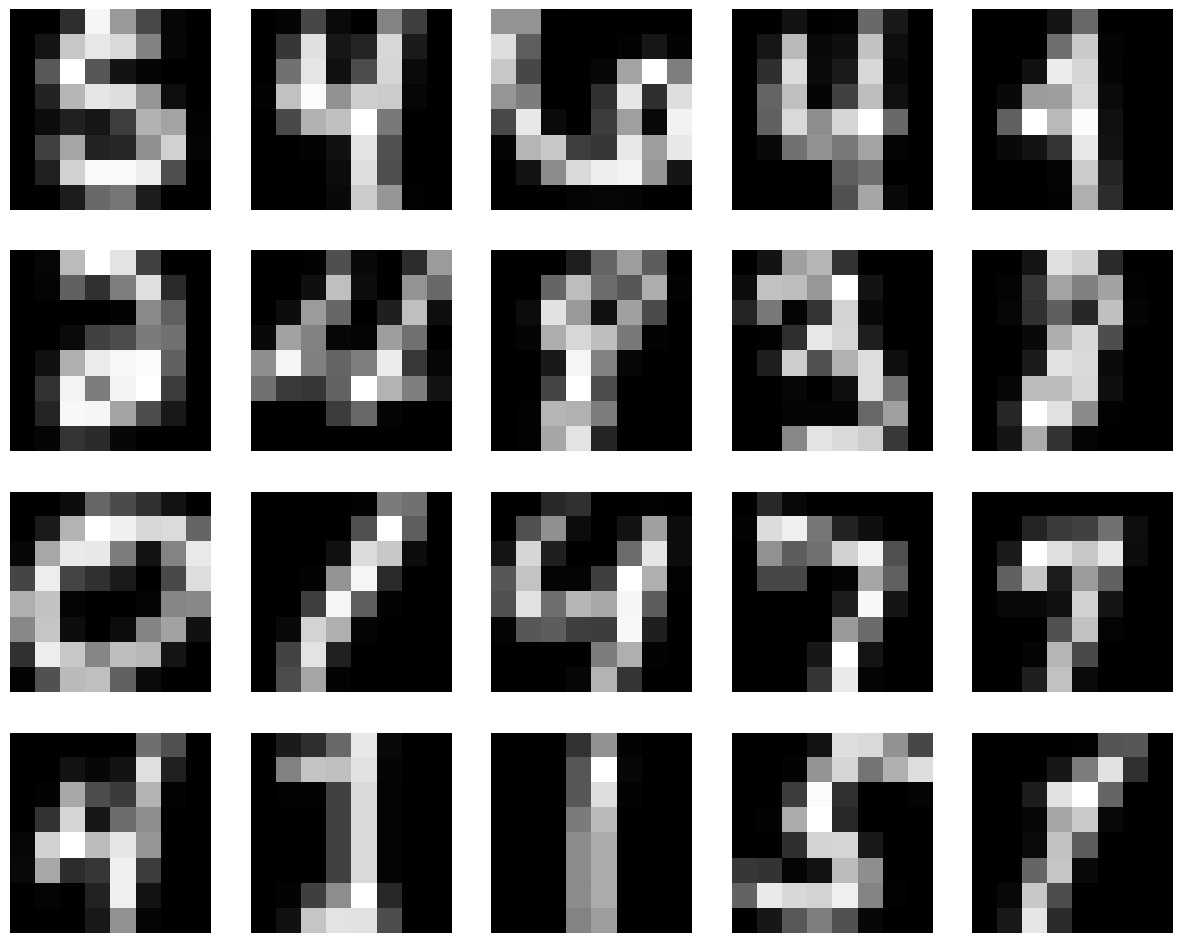

In [491]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_images[i], cmap='gray')
    ax.axis('off')  
    
plt.show()

In [492]:
images_cropped_compressed.reshape(-1, 8*8)

array([[9.17649277e-05, 2.22043516e-02, 9.53585032e-02, ...,
        4.76159287e-04, 1.54550769e-06, 0.00000000e+00],
       [0.00000000e+00, 2.45554031e-07, 5.68315613e-04, ...,
        5.29116534e-04, 1.09292781e-06, 0.00000000e+00],
       [5.40229420e-02, 1.03797888e-03, 0.00000000e+00, ...,
        7.46893886e-01, 7.87380384e-02, 0.00000000e+00],
       ...,
       [0.00000000e+00, 9.96777460e-06, 1.40536461e-02, ...,
        8.16586548e-06, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 5.40906552e-07, ...,
        4.50044246e-05, 2.82317472e-09, 0.00000000e+00],
       [0.00000000e+00, 5.60653314e-03, 1.58454442e-01, ...,
        7.32973160e-03, 1.99920508e-04, 2.05918794e-07]])

In [129]:
X_train_ex, X_test_ex, y_train_ex, y_test_ex = train_test_split(images_cropped_compressed.reshape(-1, 8*8), y, test_size=0.2, random_state=42)

In [496]:
svm_clf = SVC(gamma='scale')
svm_clf.fit(X_train_ex, y_train_ex)

SVC()

In [497]:
y_pred_ex = svm_clf.predict(X_test_ex)
print("Accuracy:", accuracy_score(y_test_ex, y_pred_ex))

Accuracy: 0.9756428571428571


Вывод: работает гораздо быстрее, в точности почти ничего не потеряли

# 5. Расширение признаков с использованием HOG

In [136]:
def create_hog_features(images):
    hog_features = []
    for image in images:
        fd, hog_image = hog(image, orientations=8, pixels_per_cell=(3, 3),
                    cells_per_block=(1, 1), visualize=True, channel_axis=None)
        hog_features.append(fd)
    return np.array(hog_features)

In [130]:
X_train_ex.shape

(56000, 64)

In [131]:
X_train_ex_hog = X_train_ex.reshape(-1, 8, 8)

In [132]:
X_train_ex_hog.shape

(56000, 8, 8)

In [133]:
X_train_ex_hog[0].shape

(8, 8)

In [134]:
X_test_ex_hog = X_test_ex.reshape(-1, 8, 8)

In [137]:
X_train_hog = create_hog_features(X_train_ex_hog)
X_test_hog = create_hog_features(X_test_ex_hog)

In [138]:
X_train_hog.shape

(56000, 32)

In [139]:
images = X_train_ex_hog[:15]

In [140]:
images.shape

(15, 8, 8)

In [141]:
def create_hog_features_one(image):
    fd, hog_image = hog(image, orientations=8, pixels_per_cell=(3, 3), cells_per_block=(2, 2), visualize=True)
    return fd, hog_image

In [518]:
images[0].shape

(8, 8)

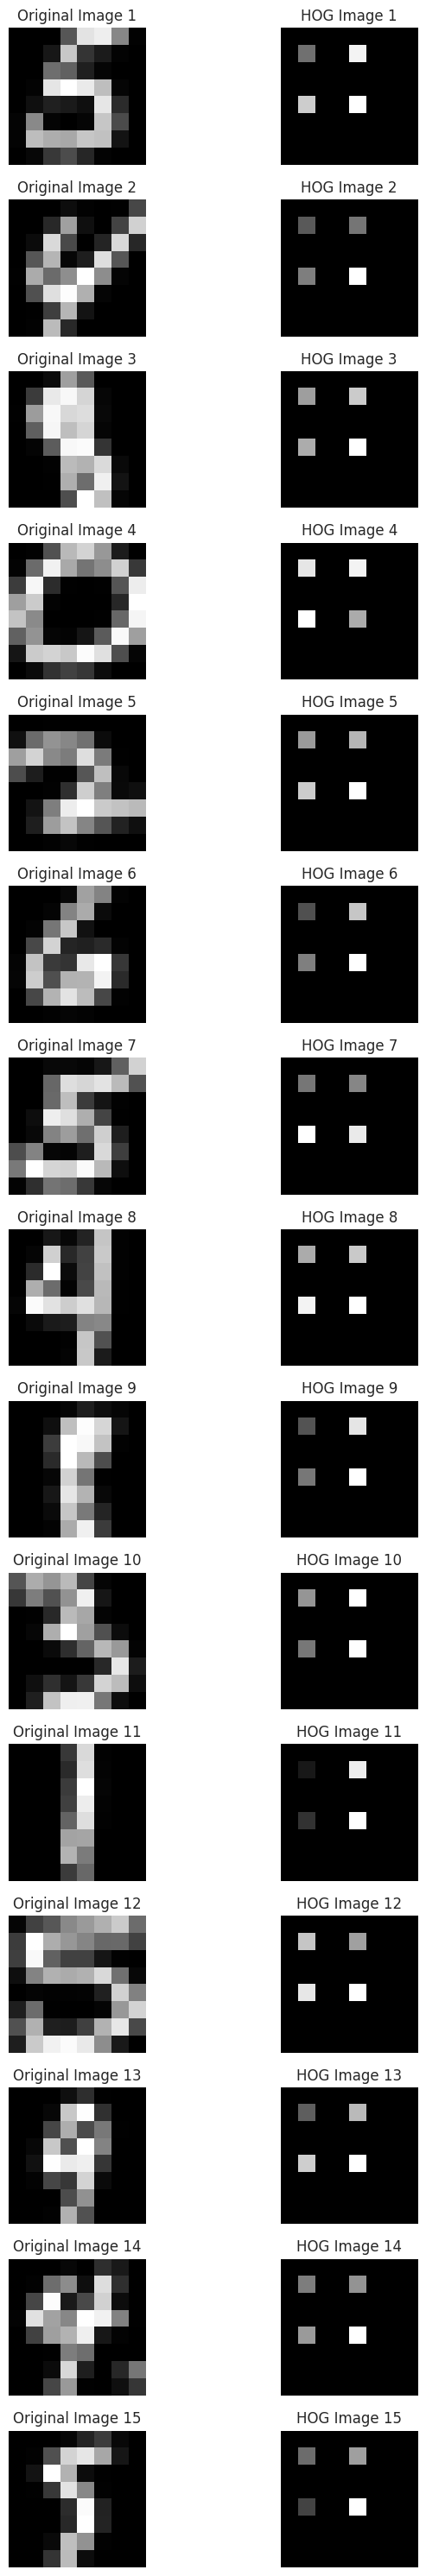

In [143]:
fig, axes = plt.subplots(nrows=len(images), ncols=2, figsize=(8, len(images) * 2))
for i, image in enumerate(images):
    fd, hog_image = create_hog_features_one(image)
    
    axes[i, 0].imshow(image if image.ndim == 2 else image[:, :, 0], cmap='gray')
    axes[i, 0].set_title(f'Original Image {i+1}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(hog_image, cmap='gray')
    axes[i, 1].set_title(f'HOG Image {i+1}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [520]:
X_train_combined = np.hstack((X_train_ex, X_train_hog))
X_test_combined = np.hstack((X_test_ex, X_test_hog))

In [326]:
svm_clf.fit(X_train_combined, y_train_ex)
y_pred_combined = svm_clf.predict(X_test_combined)

In [329]:
hog_metr = metrics(y_test_ex, y_pred_combined)

print(f"Accuracy Score with HOG features: {hog_metr[1]}")
print(f"Precision with HOG features: {hog_metr[2]}")
print(f"Recall with HOG features: {hog_metr[3]}")
print(f"F1 Score with HOG features: {hog_metr[4]}")

Accuracy Score with HOG features: 0.975
Precision with HOG features: 0.9749946389705281
Recall with HOG features: 0.975
F1 Score with HOG features: 0.9749851073246864


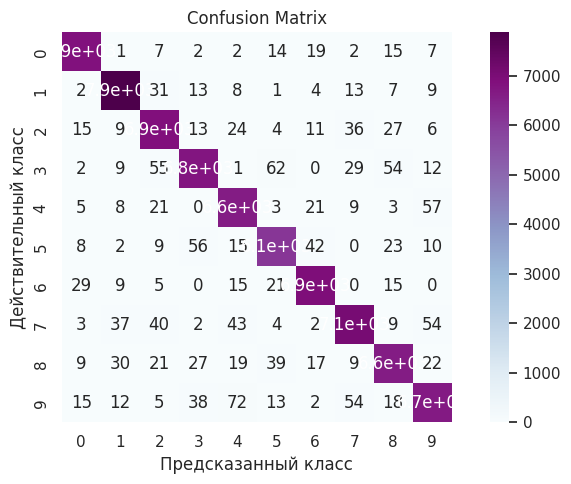

In [330]:
cm = confusion_matrix(y_test_ex, y_pred_combined)
confusion_matrix_visualisation(cm)

## Задание №2

   Теперь применим накопленные знания для классификации объектов в видеопотоке. Вы обучите SVM для классификации двух типов объектов - автомобиль и не-автомобиль (задний фон). Для этой задачи будем использовать датасеты Vehicle Image Database и Berkley Deep Drive dataset.

   Фактически в данной задаче вы также попрактикуетесь использовать HOG, но для более сложных объектов. При выполнении проекта можете ориентироваться на следующую статью на medium.com. В целом, решение этой задачи есть в интернете, но чем больше вы сделаете самостоятельно, тем сильнее вы себя прокачаете – это и есть цель курса на текущий момент.

1. Натренируйте модель для классификации изображений автомобиля, подобно тому, как вы это делали в задании №1.

        a. Вновь преобразуйте изображение в вектор. Имейте в виду, что в данном случае у вас 3х канальные RGB изображения, поэтому для каждого канала нужно будет создавать отдельный feature-vector. Также примените HOG для увеличения количества фичей в финальном векторе.
    
        b. Натренируйте SVC.
    
        c. Для отображения многомерных пространств на двумерную плоскость можете использовать t-SNE алгоритм.
    
2. Как только научитесь классифицировать отдельные изображения автомобилей - перейдём к построению рамок вокруг целевого класса (Bounding boxes - bboxes) на отдельном изображении: 

        a. Для этого сперва реализуйте метод sliding window — это метод, который фактически перемещает квадратную рамку вдоль изображения (в том числе построчно) с фиксированным шагом.
    
        b. Внутри каждой такой рамки вам необходимо запускать свой натренированный классификатор для того, чтобы понять, находится внутри текущего окна объект целевого класса или нет.
    
        c. Задайте пороговое значение метрики для того, чтобы определять, есть внутри текущей рамки объект целевого класса или нет.
    
        d. Постройте Heat Map - «тепловую карту». Это изображение, на котором вы будете демонстрировать количество пересечений соседних окон, в которых был обнаружен объект целевого класса. Чем больше таких пересечений в данной области изображения, тем больше значение цветового градиента.
    
        e. В результате построения Heat Map у вас образуется несколько цветовых пятен на изображении. Найдите крайние точки каждого пятна и по ним постройте прямоугольники. Это и будут ваши bboxes.
    
        f. Проверьте работу вашего классификатора на различных тестовых изображениях, выложенных на яндекс диске. Интерпретируйте результаты классификации.
    
3. Как только у вас получилось реализовать этот пайплайн для одного изображения - создайте функцию, которая позволит покадрово обрабатывать каждое изображение для тестового видео. Для тестов используйте видео LaGuardia_New_York.mov


# 1. EDA (Exploratory Data Analysis)

In [144]:
image = imread('data/BDD_photos/night_2.jpg') 
height, width = image.shape[:2] 
print(f"Разрешение изображения: {width} пикселей в ширину, {height} пикселей в высоту.")

Разрешение изображения: 1280 пикселей в ширину, 720 пикселей в высоту.


In [145]:
folder_path = "/home/mary/Desktop/MIPT/СКОЛТЕХ_ИНЖПРАК/SKOLTECH_ML_prep/task_4/data/BDD_photos"

In [344]:
def read_images_from_folder(folder_path):
    image_vectors = []
    file_names = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    
    for file_name in file_names:
        file_path = os.path.join(folder_path, file_name)
        try:
            image = imread(file_path)
            #image_vector = get_image_vector(image)
            #image_vectors.append(image_vector)
            image_vectors.append(image)
        except Exception as e:
            print(f"Ошибка при обработке файла {file_name}: {e}")
            
    return image_vectors

In [1356]:
images = np.array(read_images_from_folder(folder_path))

In [1357]:
def create_hog_features_one(image):
    fd, hog_image = hog(image, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True, channel_axis=2)
    return fd, hog_image

In [1358]:
images[0].shape

(720, 1280, 3)

In [355]:
images[0][0][0].shape

(3,)

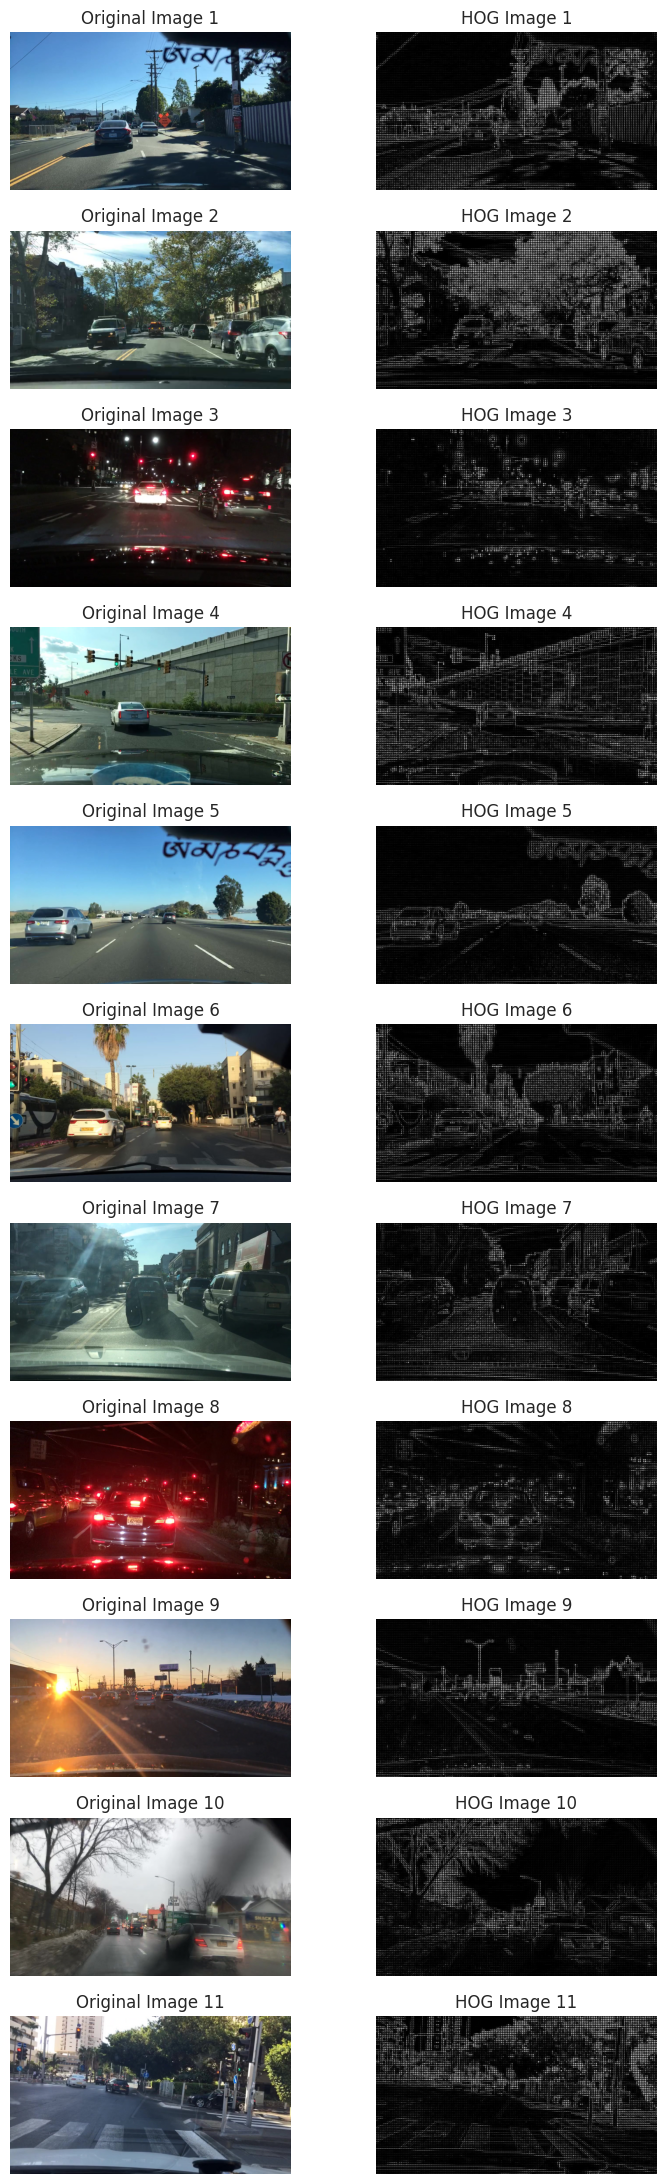

In [356]:
fig, axes = plt.subplots(nrows=len(images), ncols=2, figsize=(8, len(images) * 2))
for i, image in enumerate(images):
    fd, hog_image = create_hog_features_one(image)
        
    axes[i, 0].imshow(image)
    axes[i, 0].set_title(f'Original Image {i+1}')
    axes[i, 0].axis('off')
    
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    axes[i, 1].imshow(hog_image_rescaled, cmap='gray')
    axes[i, 1].set_title(f'HOG Image {i+1}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [59]:
fp1 = '/home/mary/Desktop/MIPT/СКОЛТЕХ_ИНЖПРАК/SKOLTECH_ML_prep/task_4/data/vehicles/Far'
fp2 = '/home/mary/Desktop/MIPT/СКОЛТЕХ_ИНЖПРАК/SKOLTECH_ML_prep/task_4/data/vehicles/Left'
fp3 = '/home/mary/Desktop/MIPT/СКОЛТЕХ_ИНЖПРАК/SKOLTECH_ML_prep/task_4/data/vehicles/MiddleClose'
fp4 = '/home/mary/Desktop/MIPT/СКОЛТЕХ_ИНЖПРАК/SKOLTECH_ML_prep/task_4/data/vehicles/Right'

fp1n = '/home/mary/Desktop/MIPT/СКОЛТЕХ_ИНЖПРАК/SKOLTECH_ML_prep/task_4/data/non-vehicles/Far'
fp2n = '/home/mary/Desktop/MIPT/СКОЛТЕХ_ИНЖПРАК/SKOLTECH_ML_prep/task_4/data/non-vehicles/Left'
fp3n = '/home/mary/Desktop/MIPT/СКОЛТЕХ_ИНЖПРАК/SKOLTECH_ML_prep/task_4/data/non-vehicles/MiddleClose'
fp4n = '/home/mary/Desktop/MIPT/СКОЛТЕХ_ИНЖПРАК/SKOLTECH_ML_prep/task_4/data/non-vehicles/Right'

In [2]:
def extract_hog_features(image, pixels_per_cell=(8, 8), cells_per_block=(2, 2), orientations=9):
    
    hog_features = []
    
    for channel in range(image.shape[2]):
        fd_channel = hog(image[:, :, channel], 
                         orientations=orientations, 
                         pixels_per_cell=pixels_per_cell, 
                         cells_per_block=cells_per_block, 
                         visualize=False, 
                         feature_vector=True)
        hog_features.append(np.array(fd_channel))

    hog_features = hog_features / (np.max(hog_features)+np.finfo(np.float32).eps)
    return hog_features

In [3]:
def compute_color_features(img, nbins=32):
    channel1_hist = np.histogram(img[:,:,0], bins=nbins)
    channel2_hist = np.histogram(img[:,:,1], bins=nbins)
    channel3_hist = np.histogram(img[:,:,2], bins=nbins)
    # Concatenate the histograms into a single feature vector
    hist_features = np.concatenate((channel1_hist[0], channel2_hist[0], channel3_hist[0]))
    hist_features = hist_features / (np.max(hist_features)+np.finfo(np.float32).eps)
    return hist_features

In [4]:
def compute_sift_features(img, ndes=10):
    descr = np.zeros((ndes, 128), dtype=np.float64)
    
    gray= cv2.cvtColor(cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype('uint8'),cv2.COLOR_BGR2GRAY)
    #gray = color.rgb2gray(img)
 
    sift = cv2.SIFT_create(ndes)
    kp, des = sift.detectAndCompute(gray,None)
    if des is not None:
        descr[:des.shape[0]] = des[:ndes]
    descr = descr / (np.max(descr)+np.finfo(np.float32).eps)
    return descr

In [5]:
def process_images_from_folder(folder_path):
    image_features = []
    file_names = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    
    for file_name in file_names:
        file_path = os.path.join(folder_path, file_name)
        try:
            image = imread(file_path)
            color_features = compute_color_features(image)
            hog_features = extract_hog_features(image)
            sift_features = compute_sift_features(image)
            image_features.append(np.concatenate((np.ravel(color_features), np.ravel(sift_features), np.ravel(hog_features))))
            
        except Exception as e:
            print(f"Ошибка при обработке файла {file_name}: {e}")
            
    return image_features

In [1579]:
images = process_images_from_folder(folder_path)
for im in images:
    print(im.shape)

(1529684,)
(1529684,)
(1529684,)
(1529684,)
(1529684,)
(1529684,)
(1529684,)
(1529684,)
(1529684,)
(1529684,)
(1529684,)


In [1580]:
#BDD
images = np.array(process_images_from_folder(folder_path))

In [64]:
v1 = np.array(process_images_from_folder(fp1))
v2 = np.array(process_images_from_folder(fp2))
v3 = np.array(process_images_from_folder(fp3))
v4 = np.array(process_images_from_folder(fp4))

In [65]:
nv1 = np.array(process_images_from_folder(fp1n))
nv2 = np.array(process_images_from_folder(fp2n))
nv3 = np.array(process_images_from_folder(fp3n))
nv4 = np.array(process_images_from_folder(fp4n))

In [66]:
vehicles_images = np.vstack((v1, v2, v3, v4))

In [67]:
vehicles_images.shape

(3425, 6668)

In [68]:
non_vehicles_images = np.vstack((nv1, nv2, nv3, nv4))

In [69]:
non_vehicles_images.shape

(3940, 6668)

In [70]:
y = np.concatenate((np.ones(vehicles_images.shape[0]), np.zeros(non_vehicles_images.shape[0])))

In [71]:
y.shape

(7365,)

In [72]:
X = np.vstack((vehicles_images, non_vehicles_images))

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [74]:
np.sum(np.isnan(X_train))

0

(array([765.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 708.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

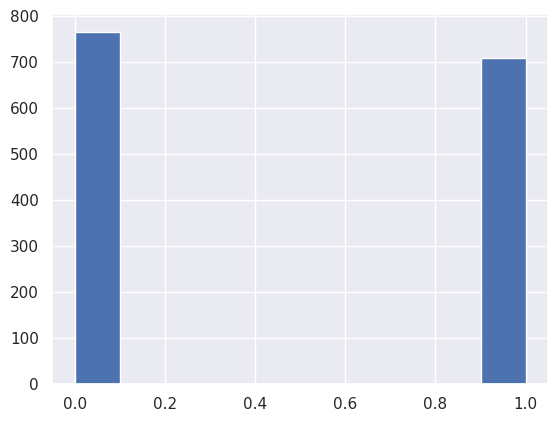

In [75]:
plt.hist(y_test)

In [76]:
svm_clf = SVC(gamma='scale', probability=True)
#svm_clf.fit(X_train, y_train)
svm_clf.fit(X, y)

SVC(probability=True)

In [77]:
y_pred = svm_clf.predict(X_test)

(array([764.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 709.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

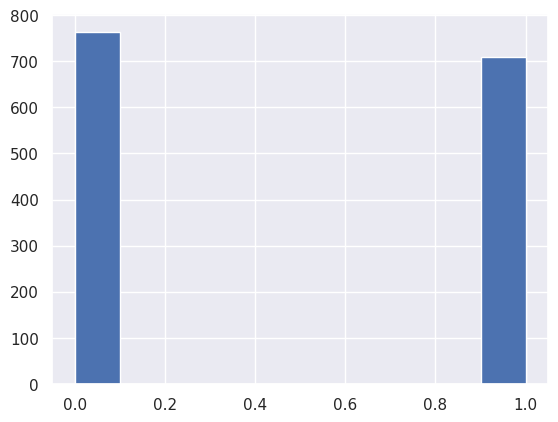

In [78]:
plt.hist(y_pred)

In [83]:
hog_metr = metrics(y_test, y_pred)

print(f"Accuracy Score with HOG features: {hog_metr[1]}")
print(f"Precision with HOG features: {hog_metr[2]}")
print(f"Recall with HOG features: {hog_metr[3]}")
print(f"F1 Score with HOG features: {hog_metr[4]}")

Accuracy Score with HOG features: 0.9993211133740665
Precision with HOG features: 0.9993220709010425
Recall with HOG features: 0.9993211133740665
F1 Score with HOG features: 0.9993211309212714


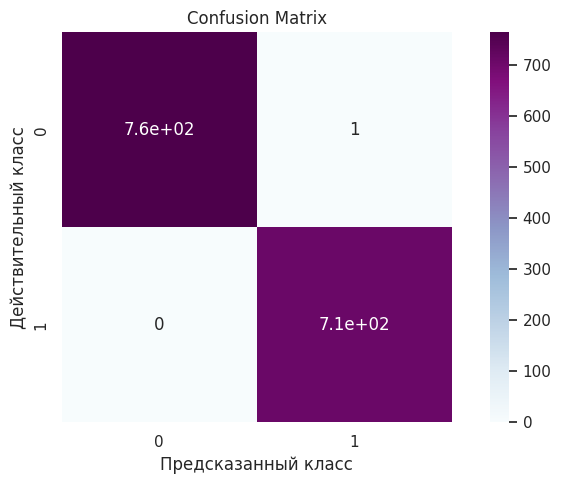

In [84]:
cm = confusion_matrix(y_test, y_pred)
confusion_matrix_visualisation(cm)

In [85]:
params = svm_clf.get_params()
params

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': True,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [86]:
filename = 'trained_svc.pkl'
pickle.dump(svm_clf, open(filename, 'wb'))

In [6]:
filename = 'trained_svc.pkl'
svm_clf = pickle.load(open(filename, 'rb'))

In [1620]:
prediction = loaded_model.predict(X_test)

In [1621]:
hog_metr = metrics(y_test, prediction)

print(f"Accuracy Score with HOG features: {hog_metr[1]}")
print(f"Precision with HOG features: {hog_metr[2]}")
print(f"Recall with HOG features: {hog_metr[3]}")
print(f"F1 Score with HOG features: {hog_metr[4]}")

Accuracy Score with HOG features: 0.9843003412969283
Precision with HOG features: 0.9843103584375812
Recall with HOG features: 0.9843003412969283
F1 Score with HOG features: 0.9843012197530893


In [293]:
test_image = imread('data/BDD_photos/night_1.jpg') 

In [294]:
test_image = resize(test_image, (480, 850))

In [295]:
test_image.shape

(480, 850, 3)

In [296]:
def sliding_window(image, window_step=64, window_size=64):
    windows = []
    for y in range(0, image.shape[0] - window_size + 1, window_step):
        for x in range(0, image.shape[1] - window_size + 1, window_step):
            windows.append(image[y:y + window_size, x:x + window_size])
    return windows

In [297]:
crops = np.array(sliding_window(test_image, 32, 64), dtype=np.float64)

In [298]:
crops.shape

(350, 64, 64, 3)

In [299]:
crops_w = crops.reshape(14, 25, 64, 64, 3)

In [300]:
crops_w.shape

(14, 25, 64, 64, 3)

In [301]:
def inverse_sliding_window(crops,  window_step=32, window_size=64):
    
    compl_image = np.zeros((480, 850, 3), dtype=np.float64)
    
    row_idx = 0
    for y in range(0, compl_image.shape[0] - window_size + 1, window_step):
        col_idx = 0
        for x in range(0, compl_image.shape[1] - window_size + 1, window_step):
            if row_idx < crops.shape[0] and col_idx < crops.shape[1]:
                compl_image[y:y + window_size, x:x + window_size] = crops[row_idx, col_idx]
                col_idx += 1
        row_idx += 1
    
    return compl_image

In [302]:
compl_img = inverse_sliding_window(crops_w, 32, 64)

In [303]:
compl_img.shape

(480, 850, 3)

In [304]:
#compl_img2 = cv2.cvtColor(compl_img, cv2.COLOR_RGB2RGB)

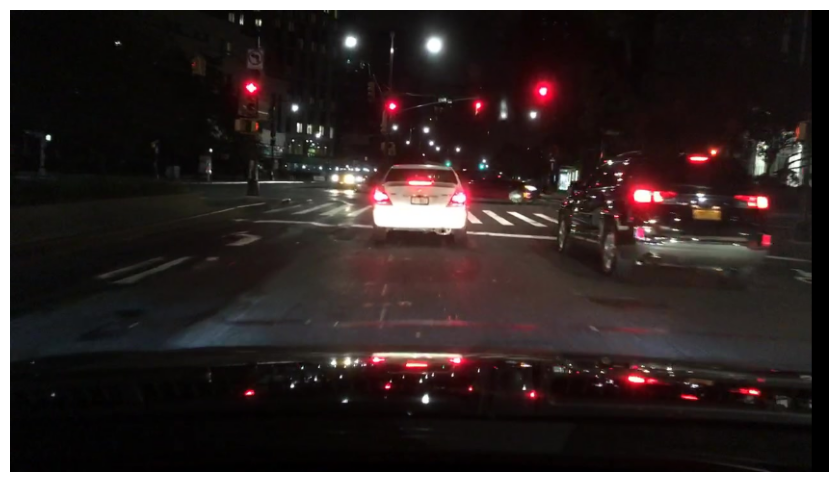

In [305]:
plt.figure(figsize = (12, 6))
plt.imshow(compl_img)
plt.axis('off')

plt.show()

In [306]:
crops_test = []
for cr in crops:
    #cr = resize(cr, (64, 64))
    #print(cr)
    #cr = cr.astype(np.float32)
    #print(cr)    
    #cr = cv2.cvtColor(cr, cv2.COLOR_RGB2BGR)
    color_features = compute_color_features(cr)
    hog_features = extract_hog_features(cr)
    sift_features = compute_sift_features(cr)
    crops_test.append(np.concatenate((np.ravel(color_features), np.ravel(sift_features), np.ravel(hog_features))))

In [307]:
crops_test = np.array(crops_test)
crops_test.shape

(350, 6668)

In [308]:
crop_proba = svm_clf.predict_proba(crops_test)

In [309]:
crop_proba.shape

(350, 2)

In [310]:
crop_proba_w = crop_proba[:, 1].reshape(14, 25);

In [311]:
crop_proba_w_tresholded = np.where(crop_proba_w < 0.4, 0, crop_proba_w)

In [312]:
np.max(crop_proba_w)

0.9999993203326222

In [313]:
crop_proba_w = resize(crop_proba_w, (704, 1280));
crop_proba_w_tresholded = resize(crop_proba_w_tresholded, (704, 1280));

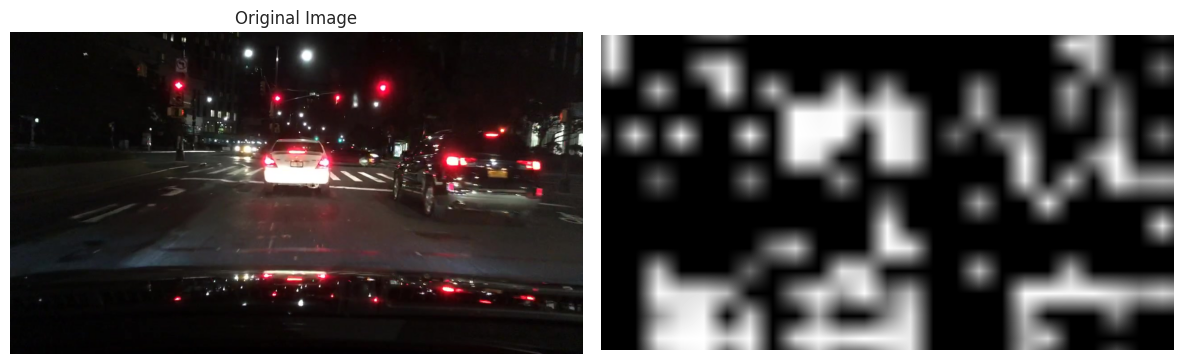

In [314]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 18))

axes[0].imshow(imread('data/BDD_photos/night_1.jpg'))
axes[0].set_title(f'Original Image')
axes[0].axis('off')

axes[1].imshow(crop_proba_w_tresholded, cmap = 'gray')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [315]:
def generate_bounding_boxes(image_height, image_width, window_size=64, step=32):
    num_windows_x = (image_width - window_size) // step + 1
    num_windows_y = (image_height - window_size) // step + 1
    
    bounding_boxes = []
    
    for y in range(num_windows_y):
        for x in range(num_windows_x):
            top_left_x = x * step
            top_left_y = y * step
            bottom_right_x = top_left_x + window_size
            bottom_right_y = top_left_y + window_size
            
            bounding_boxes.append([top_left_x, top_left_y, bottom_right_x, bottom_right_y])
    
    return np.array(bounding_boxes)

In [316]:
bounding_boxes = generate_bounding_boxes(480, 850)
bounding_boxes

array([[  0,   0,  64,  64],
       [ 32,   0,  96,  64],
       [ 64,   0, 128,  64],
       ...,
       [704, 416, 768, 480],
       [736, 416, 800, 480],
       [768, 416, 832, 480]])

In [317]:
print(bounding_boxes.shape)

(350, 4)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Filtered Boxes: [array([128, 416, 192, 480]), array([352, 416, 416, 480]), array([256, 128, 320, 192]), array([384, 128, 448, 192]), array([320,  96, 384, 160]), array([576, 352, 640, 416]), array([384, 288, 448, 352]), array([704, 160, 768, 224]), array([192, 416, 256, 480]), array([ 64, 352, 128, 416]), array([ 96, 128, 160, 192]), array([160,  64, 224, 128]), array([192, 128, 256, 192]), array([ 0,  0, 64, 64])]


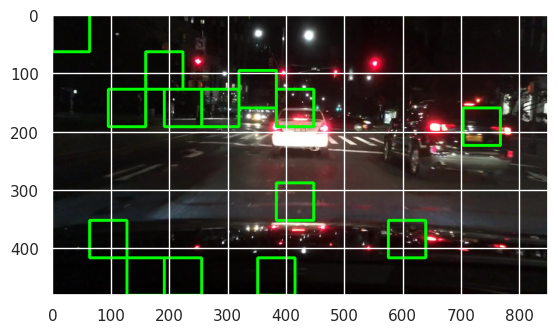

In [318]:
image_copy = test_image.copy()
indices = cv2.dnn.NMSBoxes(bboxes=bounding_boxes, scores=crop_proba[:,1], 
                           score_threshold=0.95, nms_threshold=0.5)
# Filter out the boxes based on the NMS result
filtered_boxes = [bounding_boxes[i] for i in indices.flatten()]
# Draw the filtered boxes on the image
for xmin, ymin, xmax, ymax in filtered_boxes:
    cv2.rectangle(image_copy, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)

plt.imshow(image_copy)
#cv2.waitKey(0)
print("Filtered Boxes:", filtered_boxes)

# Подготовленный код

In [102]:
test_image = imread('data/BDD_photos/highway.jpg')
print(test_image.shape)

(720, 1280, 3)


In [103]:
def calc_features_crop(cr):
    color_features = compute_color_features(cr)
    sift_features = compute_sift_features(cr)
    hog_features = extract_hog_features(cr)
    return np.concatenate((np.ravel(color_features), np.ravel(sift_features), np.ravel(hog_features)))

In [104]:
def prepare_predict(img, window_size=64, step=32):
    crops = np.array(sliding_window(img, step, window_size), dtype=np.float64)
    bb = generate_bounding_boxes(img.shape[0], img.shape[1], window_size=window_size, step=step)
    crops_test = []

    #for crop in crops:
    # Чуть-чуть оптимизаци:)
    pool_obj = multiprocessing.Pool()
    crops_test = pool_obj.map(calc_features_crop, crops)
    pool_obj.close()
        
    crops_test = np.array(crops_test)

    crop_proba = svm_clf.predict_proba(crops_test)
    return bb, crop_proba

In [105]:
def prepare_predictions(img, window_size=64, step=32):
    scale1 = 2.5
    scale2 = 1.5
    scale3 = 0.8
    img1 = resize(img, (test_image.shape[0] // scale1, test_image.shape[1] // scale1))
    img2 = resize(img, (test_image.shape[0] // scale2, test_image.shape[1] // scale2))
    img3 = resize(img, (test_image.shape[0] // scale3, test_image.shape[1] // scale3))
    bb1, crop_proba1 = prepare_predict(img1, window_size=64, step=32)
    bb1 = np.int_(bb1*scale1)
    bb2, crop_proba2 = prepare_predict(img2, window_size=64, step=32)
    bb2 = np.int_(bb2*scale2)
    bb3, crop_proba3 = prepare_predict(img3, window_size=64, step=32)
    bb3 = np.int_(bb3*scale3)

    return np.concatenate((bb1, bb2, bb3)), np.concatenate((crop_proba1, crop_proba2, crop_proba3))

In [106]:
indices = cv2.dnn.NMSBoxes(bboxes=bb, scores=crop_proba[:,1], \
                           score_threshold=0.995, nms_threshold=0.05, top_k=5)

filtered_boxes = [bb[i] for i in indices.flatten()]

for xmin, ymin, xmax, ymax in filtered_boxes:
    cv2.rectangle(image_copy, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)
plt.imshow(image_copy)

NameError: name 'bb' is not defined

In [107]:
image_copy = test_image.copy()
image_copy = resize(image_copy, (480, 850))
bb, crop_proba = prepare_predict(image_copy, window_size=64, step=16)

indices = cv2.dnn.NMSBoxes(bboxes=bb, scores=crop_proba[:,1], \
                           score_threshold=0.95, nms_threshold=0.3)

filtered_boxes = [bb[i] for i in indices.flatten()]

for xmin, ymin, xmax, ymax in filtered_boxes:
    cv2.rectangle(image_copy, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)

plt.imshow(image_copy)

#print("Filtered Boxes:", filtered_boxes)

NameError: name 'generate_bounding_boxes' is not defined

In [46]:
video_path = 'data/BDD_videos/Highway.mov'

In [51]:
def process_frame(image):
    image = cv2.resize(image, (850, 480))
    
    bb, crop_proba = prepare_predict(image, window_size=64, step=64)

    indices = cv2.dnn.NMSBoxes(bboxes=bb, scores=crop_proba[:,1], \
                               score_threshold=0.01, nms_threshold=0.3)

    filtered_boxes = [bb[i] for i in np.ravel(indices)]

    for xmin, ymin, xmax, ymax in filtered_boxes:
        cv2.rectangle(image_copy, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)
    
    return image

In [52]:
cap = cv2.VideoCapture(video_path)
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('output.avi', fourcc, 20.0, (850, 480))
i = 0
while(cap.isOpened() and i < 20):
    ret, frame = cap.read()
    if ret:
        frame_processed = process_frame(frame)
        out.write(frame_processed)
        i += 1
        print(i)
    else:
        break

cap.release()
out.release()

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


In [ ]:
cap.release()
out.release()